In [1]:
# Plotting mortality rate for SSP245 and ARISE

In [2]:
import os
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np

In [3]:
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

In [11]:
bmr = xr.open_dataarray(f"{BMR_DIR}GBD_BMR_Country_Mask_COPD_popgrid_1990-2009.nc")
population = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000-2100.nc")

In [49]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, start, end, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ens = []

    for ens_num in range(1, 11):
        ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{start}-{end}.nc"))

    da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        da = land_filter(da)

    return da


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [ ]:
o3_arise = merge_ensembles(O3_DIR, "OSDMA8_BC_popgrid", "ARISE", 2035, 2069)
o3_ssp245 = merge_ensembles(O3_DIR, "OSDMA8_BC_popgrid", "SSP245", 2020, 2069)

In [12]:
o3_arise = xr.open_dataarray(f"{O3_DIR}OSDMA8_BC_popgrid_CESM2_ARISE_01_2035-2069.nc")

In [13]:
RR_10ppb = 1.074  # From GBD21, relative risk for 10ppb increase in OSDMA8
# RR = np.exp(beta*(x-TMREL)); x = o3
beta = np.log(RR_10ppb)/10
TMREL = 32.4  # From GBD21, update to include lower and upper bounds too

In [43]:
# === Attributal fraction ===
def att_frac(o3, TMREL, beta):
    # O3_diff = X - TMREL
    O3_diff = o3 - TMREL
    TMREL_O3 = xr.where(O3_diff > 0, O3_diff, 0)  # where the difference <0 set to 0
    
    # RR = np.exp(beta*(x-TMREL))
    RR = np.exp(beta * TMREL_O3)
    AF = (RR - 1)/RR
    return AF

In [15]:
# === Mortality equation ===
def mortality(AF, bmr, pop):
    M = AF * bmr * pop
    return M

In [16]:
# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da

In [48]:
for year in range(2040, 2070, 10):
    af = att_frac(o3_arise.sel(year=year), TMREL, beta)
    m = mortality(af, bmr, population.sel(year=year))

    print(weighted_sum(m))

    # Create DataArray filled with NaNs
    global_M_array = xr.DataArray(
        np.full((len(m.lat), len(m.lon)), np.nan),
        coords={"lat": m.lat.values, "lon": m.lon.values},
        dims=["lat", "lon"]
    )

    # Loop over countries, add the population for each country and apply using country mask
    for i in range(204):
        mask = masks_interp.isel(country=i)
        country = masks_interp.isel(country=i)["country"]
        M_country = weighted_sum(xr.where(masks_interp.isel(country=i) == 1, m.sel(quantile="median"), np.nan)) # mortality of country
        global_M_array = global_M_array.where(mask == 0, M_country)

    # Save the global array? Then could use it later?

<xarray.DataArray (quantile: 3)> Size: 24B
array([375642.70662099, 437395.747872  , 495084.60901257])
Coordinates:
    year      int64 8B 2040
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'
<xarray.DataArray (quantile: 3)> Size: 24B
array([353701.35711202, 413231.98658836, 469099.57881082])
Coordinates:
    year      int64 8B 2050
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'
<xarray.DataArray (quantile: 3)> Size: 24B
array([335267.98002151, 392958.08378788, 447383.13191852])
Coordinates:
    year      int64 8B 2060
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'


In [19]:
# Looking at the year 2050 - must pick a year otherwise it times out
af = att_frac(o3_arise.sel(year=2050), TMREL, beta)

In [22]:
m = mortality(af, bmr, population.sel(year=2050))

In [47]:
print(weighted_sum(m))

<xarray.DataArray (quantile: 3)> Size: 24B
array([353701.35711202, 413231.98658836, 469099.57881082])
Coordinates:
    year      int64 8B 2050
  * quantile  (quantile) <U6 72B 'lower' 'median' 'upper'
    region    <U26 104B 'Western Sub-Saharan Africa'


In [25]:
masks = xr.open_dataarray(f"{BMR_DIR}GBD_Country_Masks_0.10_newlabels.nc")

In [27]:
masks_lat_mask = xr.ufuncs.logical_and(masks.lat.values <= population.lat.values.max(), masks.lat.values >= population.lat.values.min())
new_masks = masks.sel(lat=masks_lat_mask)
masks_interp = new_masks.interp(lat=population.lat, lon=population.lon, method="linear")

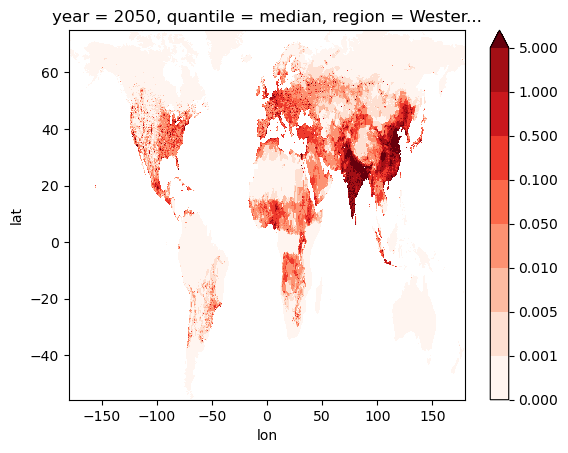

In [24]:
m.sel(quantile="median").plot(cmap="Reds", levels=[0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5])

In [28]:
# Create DataArray filled with NaNs
global_M_array = xr.DataArray(
    np.full((len(m.lat), len(m.lon)), np.nan),
    coords={"lat": m.lat.values, "lon": m.lon.values},
    dims=["lat", "lon"]
)

In [29]:
# Loop over countries, add the population for each country and apply using country mask
for i in range(204):
    mask = masks_interp.isel(country=i)
    country = masks_interp.isel(country=i)["country"]
    M_country = weighted_sum(xr.where(masks_interp.isel(country=i) == 1, m.sel(quantile="median"), np.nan)) # mortality of country
    global_M_array = global_M_array.where(mask == 0, M_country)

In [30]:
# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)

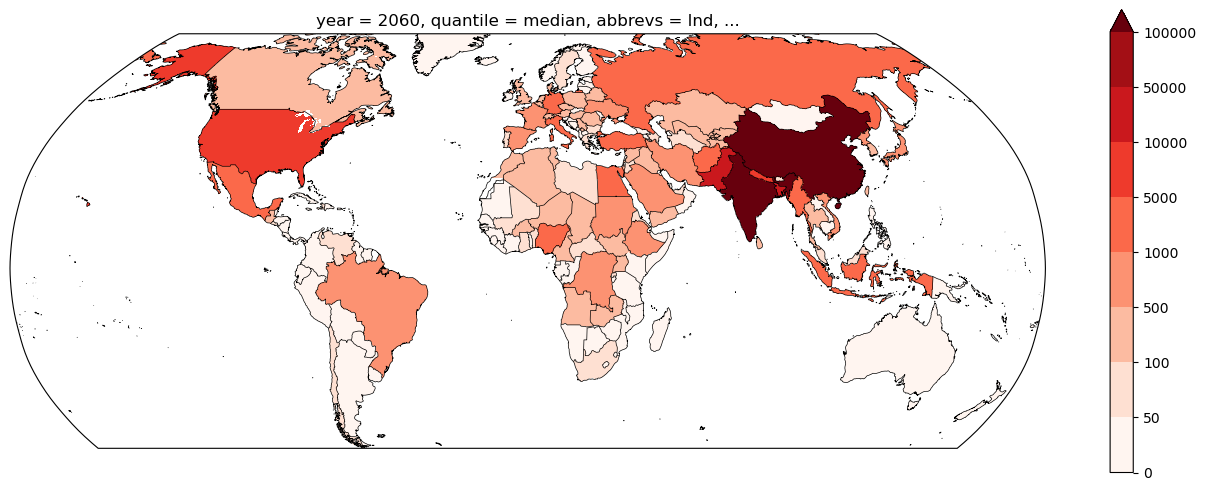

In [50]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
land_filter(global_M_array).plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000])
ax.coastlines(resolution="50m", color='k', linewidth=0.5)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.5)
#regionmask.defined_regions.natural_earth_v5_0_0.countries_110.plot(add_label=False)


In [ ]:
af_ssp245 = att_frac(o3_ssp245, TMREL, beta)
af_arise = att_frac(o3_arise, TMREL, beta)

In [ ]:
# Pick a year
m_ssp245 = mortality(af_ssp245, bmr, population)
m_arise = mortality(af_arise, bmr, population)